# Introduction

This notebook focuses on the construction and preparation of machine learning–oriented datasets derived from the synthetic program evaluation database developed for this DBA research project.

The objective is to transform the existing relational structure into two analytically consistent datasets corresponding to the two levels of analysis used in this study: the activity level and the project level. These datasets preserve the hierarchical relationships of the original data while providing flat analytical structures suitable for downstream machine learning and explainable AI analyses.

- The project-level dataset integrates project evaluation dimensions, credibility scores, and contextual variables from multiple sources, including mandates, volunteers, components, and capacities, to support project-level analytical tasks.

- The activity-level dataset enriches individual activity records with contextual and relational information from associated projects and entities while preserving variation in operational characteristics.

These datasets provide a structured foundation for the subsequent exploratory data analysis, feature engineering, explainability, and machine learning analyses.

## 1-Data Loading and Overview

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Lists is excluded because it only contains UI dropdown reference values
# and does not represent analytical or machine learning–relevant data.

file_path = "/kaggle/input/datasets/jfjutras07/data-simulation-dataset/3-Data_Simulation_Dataset.xlsx"

xls = pd.ExcelFile(file_path)
sheet_names = [s for s in xls.sheet_names if s != "Lists"]

dataframes = {}

for sheet in sheet_names:
    dataframes[sheet] = pd.read_excel(xls, sheet_name=sheet)

overview = pd.DataFrame({
    "table_name": sheet_names,
    "n_rows": [dataframes[s].shape[0] for s in sheet_names],
    "n_cols": [dataframes[s].shape[1] for s in sheet_names]
})

overview

,table_name,n_rows,n_cols
0,Activity,196,13
1,Activity_Agg,50,42
2,Activity_Partner,312,2
3,Capacity,7,2
4,Component,60,3
5,Mandate,16,8
6,Mandate_Capacity,16,2
7,Partner,5,4
8,Project,50,71
9,Risk,11,5


**Elements in the Activity_Partner table, where some rows had disappeared, had to be modified. This explains the difference between notebooks 2 and 3, without any impact on the simulation.**

## 2-Project-Level Feature Construction from Activity Aggregates

This section derives project-level performance and complexity indicators from activity-level aggregates. Each construct is summarized using the same statistical descriptors as the other project features, including mean, standard deviation, minimum, maximum, and median. This ensures full consistency with the existing feature structure while avoiding the inclusion of raw activity-level variables in the project dataset.

In [2]:
# Dataframe Naming
df_activity = dataframes["Activity"].copy()
df_activity_agg = dataframes["Activity_Agg"].copy()
df_activity_partner = dataframes["Activity_Partner"].copy()

df_capacity = dataframes["Capacity"].copy()
df_component = dataframes["Component"].copy()

df_mandate = dataframes["Mandate"].copy()
df_mandate_capacity = dataframes["Mandate_Capacity"].copy()

df_partner = dataframes["Partner"].copy()
df_project = dataframes["Project"].copy()

df_risk = dataframes["Risk"].copy()
df_risk_project = dataframes["Risk_Project"].copy()

df_volunteer = dataframes["Volunteer"].copy()

In [3]:
# Create activity-level performance and complexity scores
df_activity["performance"] = (df_activity["cost"] + df_activity["time"]) / 2
df_activity["complexity"] = (df_activity["novelty"] + df_activity["effort"]) / 2

# Aggregate derived scores at project level
perf_complex = (
    df_activity
    .groupby("id_project")
    .agg({
        "performance": ["mean", "std", "min", "max", "median"],
        "complexity": ["mean", "std", "min", "max", "median"]
    })
)

# Flatten column names
perf_complex.columns = ["_".join(col) for col in perf_complex.columns]
perf_complex = perf_complex.reset_index()

# Replace undefined standard deviations
std_columns = [c for c in perf_complex.columns if c.endswith("_std")]
perf_complex[std_columns] = perf_complex[std_columns].fillna(0)

# Merge into Project
df_project = df_project.merge(perf_complex, on="id_project", how="left")

df_project.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 81 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_project            50 non-null     int64  
 1   id_component          50 non-null     int64  
 2   id_mandate            50 non-null     int64  
 3   project_title         50 non-null     object 
 4   description           50 non-null     object 
 5   project_type          50 non-null     object 
 6   project_class         50 non-null     object 
 7   use_mean              50 non-null     float64
 8   use_std               50 non-null     float64
 9   use_min               50 non-null     int64  
 10  use_max               50 non-null     int64  
 11  use_median            50 non-null     int64  
 12  quality_mean          50 non-null     float64
 13  quality_std           50 non-null     float64
 14  quality_min           50 non-null     int64  
 15  quality_max           50 

## 3-Construction of the Project Dataset

This section transforms the relational project data into a machine learning–oriented dataset by integrating relevant information from the project, mandate, volunteer, component, and capacity tables. Descriptive text fields used only for interpretation are removed, while analytical variables are reorganized into a consistent structure combining contextual characteristics, project evaluation dimensions, credibility scores, and the target outcome for subsequent analytical modeling.

In [4]:
# Merge contextual information into the Project table
# Volunteer information
df_project = df_project.merge(
    df_mandate[
        ["id_mandate", "id_volunteer", "year", "duration"]
    ],
    on="id_mandate",
    how="left"
)

df_project = df_project.merge(
    df_volunteer[
        [
            "id_volunteer",
            "age_group",
            "gender",
            "origin",
            "education",
            "previous_mandates"
        ]
    ],
    on="id_volunteer",
    how="left"
)

# Component information
df_project = df_project.merge(
    df_component[
        ["id_component", "id_capacity", "component_name"]
    ],
    on="id_component",
    how="left"
)

# Capacity information
df_project = df_project.merge(
    df_capacity[
        ["id_capacity", "capacity_name"]
    ],
    on="id_capacity",
    how="left"
)

# Add number of activities per project
df_project = df_project.merge(
    df_activity_agg[["id_project", "n_activities"]],
    on="id_project",
    how="left"
)

In [5]:
# Keep analytical variables only and reorganize the final Project dataset
df_project = df_project[[
    # Identifier
    "id_project",
    "id_mandate",

    # Project context
    "project_type",
    "project_class",
    "n_activities",
    "year",
    "duration",
    "component_name",
    "capacity_name",

    # Volunteer characteristics
    "age_group",
    "gender",
    "origin",
    "education",
    "previous_mandates",

    # Performance
    "performance_mean", "performance_std", "performance_min", "performance_max", "performance_median",
    "complexity_mean", "complexity_std", "complexity_min", "complexity_max", "complexity_median",

    "use_mean", "use_std", "use_min", "use_max", "use_median",
    "quality_mean", "quality_std", "quality_min", "quality_max", "quality_median",
    "reach_mean", "reach_std", "reach_min", "reach_max", "reach_median",
    "results_mean", "results_std", "results_min", "results_max", "results_median",
    "satisfaction_mean", "satisfaction_std", "satisfaction_min", "satisfaction_max", "satisfaction_median",
    "alignment_mean", "alignment_std", "alignment_min", "alignment_max", "alignment_median",
    "durability_mean", "durability_std", "durability_min", "durability_max", "durability_median",
    "resilience_mean", "resilience_std", "resilience_min", "resilience_max", "resilience_median",
    "collaboration_mean", "collaboration_std", "collaboration_min", "collaboration_max", "collaboration_median",
    "stability_mean", "stability_std", "stability_min", "stability_max", "stability_median",

    # Certainty scores
    "CS_performance",
    "CS_complexity",
    "CS_use",
    "CS_quality",
    "CS_reach",
    "CS_results",
    "CS_satisfaction",
    "CS_alignment",
    "CS_durability",
    "CS_resilience",
    "CS_collaboration",
    "CS_stability",

    # Target
    "status"
]]

df_project.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 87 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_project            50 non-null     int64  
 1   id_mandate            50 non-null     int64  
 2   project_type          50 non-null     object 
 3   project_class         50 non-null     object 
 4   n_activities          50 non-null     int64  
 5   year                  50 non-null     object 
 6   duration              50 non-null     object 
 7   component_name        50 non-null     object 
 8   capacity_name         50 non-null     object 
 9   age_group             50 non-null     object 
 10  gender                50 non-null     object 
 11  origin                50 non-null     object 
 12  education             50 non-null     object 
 13  previous_mandates     50 non-null     object 
 14  performance_mean      50 non-null     float64
 15  performance_std       50 

## 4-Construction of the Activity-Level Dataset

This section builds a machine learning–oriented activity dataset by enriching each activity with contextual information from related project, mandate, volunteer, component, capacity, and partner tables. The objective is to preserve the contextual relationships between activities and higher-level entities within the data structure while transforming the information into a flat analytical format suitable for subsequent analytical modeling and pattern discovery at the activity level.

In [6]:
# Merge contextual information into the Activity table
# Project information
df_activity = df_activity.merge(
    df_project[
        ["id_project", "id_mandate", "project_type", "project_class"]
    ],
    on="id_project",
    how="left"
)

# Mandate - Volunteer link
df_activity = df_activity.merge(
    df_mandate[
        ["id_mandate", "id_volunteer"]
    ],
    on="id_mandate",
    how="left"
)

# Volunteer information
df_activity = df_activity.merge(
    df_volunteer[
        [
            "id_volunteer",
            "age_group",
            "gender",
            "origin",
            "education",
            "previous_mandates"
        ]
    ],
    on="id_volunteer",
    how="left"
)

# Partner information
df_partner_full = df_activity_partner.merge(
    df_partner,
    on="id_partner",
    how="left"
)

df_partner_agg = df_partner_full.groupby("id_activity").agg({
    "organization_size": "mean",
    "years_collaboration": "mean"
}).reset_index()

df_activity = df_activity.merge(
    df_partner_agg,
    on="id_activity",
    how="left"
)

In [7]:
# Keep analytical variables only
df_activity = df_activity[
    [
        "id_activity",
        "id_project",
        "activity_type",
        "deliverable_associated",
        "age_group",
        "gender",
        "origin",
        "education",
        "previous_mandates",
        "organization_size",
        "years_collaboration",
        "project_type",
        "project_class",
        "cost",
        "time",
        "novelty",
        "effort",
        "CS_cost",
        "CS_time",
        "CS_novelty",
        "CS_effort"
    ]
]

# Final validation
df_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_activity             196 non-null    int64  
 1   id_project              196 non-null    int64  
 2   activity_type           196 non-null    object 
 3   deliverable_associated  196 non-null    object 
 4   age_group               196 non-null    object 
 5   gender                  196 non-null    object 
 6   origin                  196 non-null    object 
 7   education               196 non-null    object 
 8   previous_mandates       196 non-null    object 
 9   organization_size       196 non-null    float64
 10  years_collaboration     196 non-null    float64
 11  project_type            196 non-null    object 
 12  project_class           196 non-null    object 
 13  cost                    196 non-null    int64  
 14  time                    196 non-null    in

## 5-Exploratory Data Analysis

This section presents a concise exploratory data analysis of the simulated datasets prior to their analytical validation. The objective is to conduct preliminary quality checks, including structural integrity assessment, distributional plausibility, and overall readiness for subsequent analyses. This exploratory step is intended to identify potential inconsistencies rather than provide a comprehensive statistical assessment.

Given the synthetic nature of the data, the EDA is intentionally limited to structural validation, descriptive distributional analysis, and preliminary correlation assessment. A more detailed and rigorous analysis will be conducted during the official research phase.

### Project-Level Dataset

In [8]:
df = df_project.copy()

# Basic Structure
print("Shape:", df.shape)

# Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nMissing values:\n", missing if len(missing) > 0 else "No missing values")

# Duplicates
print("\nDuplicate id_project:", df["id_project"].duplicated().sum())
print("Full row duplicates:", df.duplicated().sum())

# Target distribution
print("\nStatus distribution:\n", df["status"].value_counts())
print("\nStatus proportions:\n", df["status"].value_counts(normalize=True))

Shape: (50, 87)

Missing values:
 No missing values

Duplicate id_project: 0
Full row duplicates: 0

Status distribution:
 status
Completed (served its purpose)    18
Completed (operations ongoing)    15
On Hold                            8
Discontinued                       4
Ongoing                            4
Completed (superseded)             1
Name: count, dtype: int64

Status proportions:
 status
Completed (served its purpose)    0.36
Completed (operations ongoing)    0.30
On Hold                           0.16
Discontinued                      0.08
Ongoing                           0.08
Completed (superseded)            0.02
Name: proportion, dtype: float64


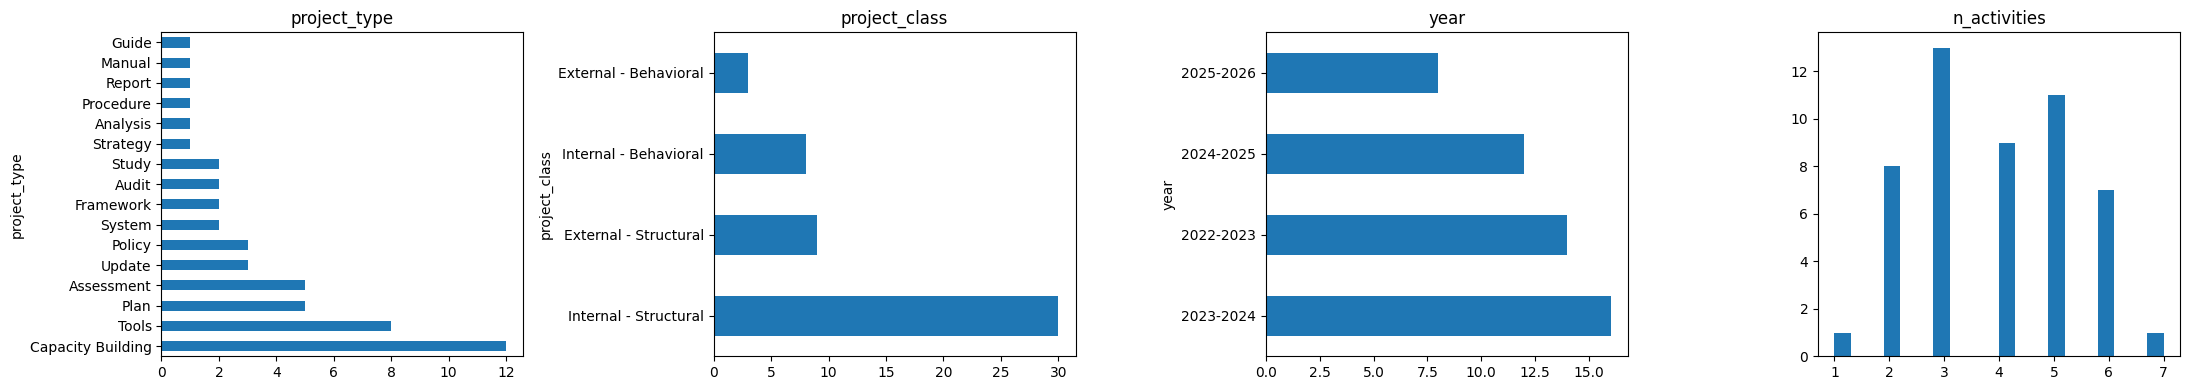

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

df["project_type"].value_counts().plot(kind="barh", ax=axes[0])
axes[0].set_title("project_type")

df["project_class"].value_counts().plot(kind="barh", ax=axes[1])
axes[1].set_title("project_class")

df["year"].value_counts().plot(kind="barh", ax=axes[2])
axes[2].set_title("year")

axes[3].hist(df["n_activities"].dropna(), bins=20)
axes[3].set_title("n_activities")

plt.tight_layout()
plt.show()

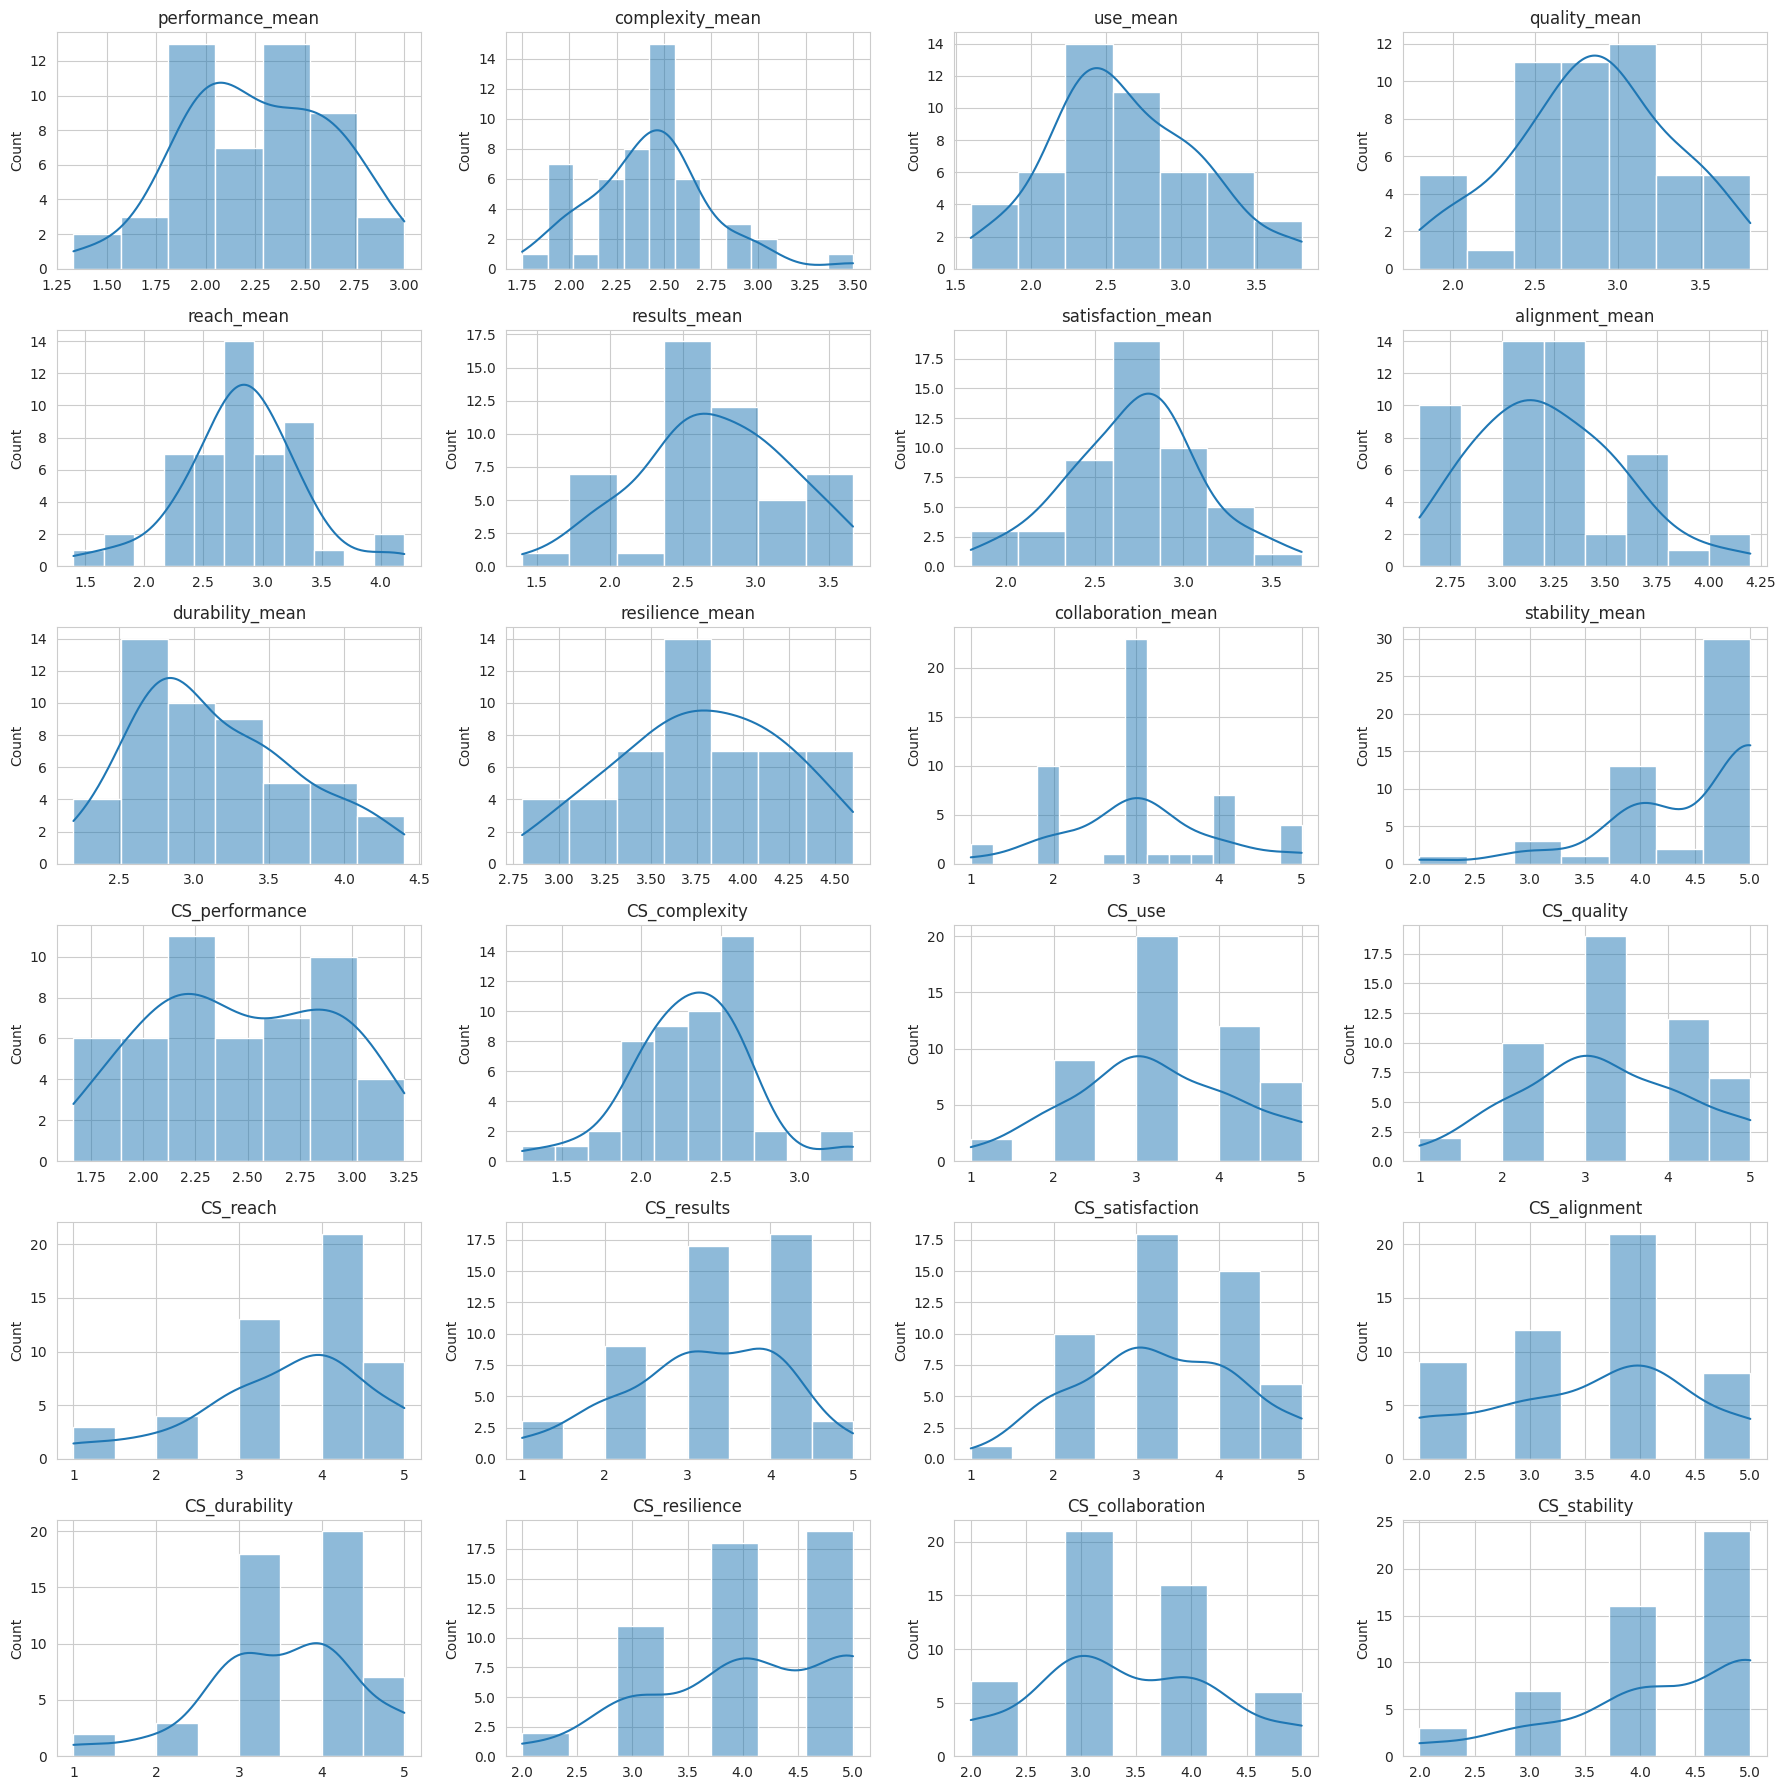

In [10]:
import seaborn as sns

sns.set_style("whitegrid")

score_cols = [
    "performance_mean","complexity_mean",
    "use_mean","quality_mean",
    "reach_mean","results_mean",
    "satisfaction_mean","alignment_mean",
    "durability_mean","resilience_mean",
    "collaboration_mean","stability_mean",
    "CS_performance","CS_complexity",
    "CS_use","CS_quality",
    "CS_reach","CS_results",
    "CS_satisfaction","CS_alignment",
    "CS_durability","CS_resilience",
    "CS_collaboration","CS_stability"
]

cols = [c for c in score_cols if c in df_project.columns]

ncols = 4
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3*nrows))
axes = axes.flatten()

for i, c in enumerate(cols):
    sns.histplot(df_project[c], kde=True, ax=axes[i])
    axes[i].set_title(c)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

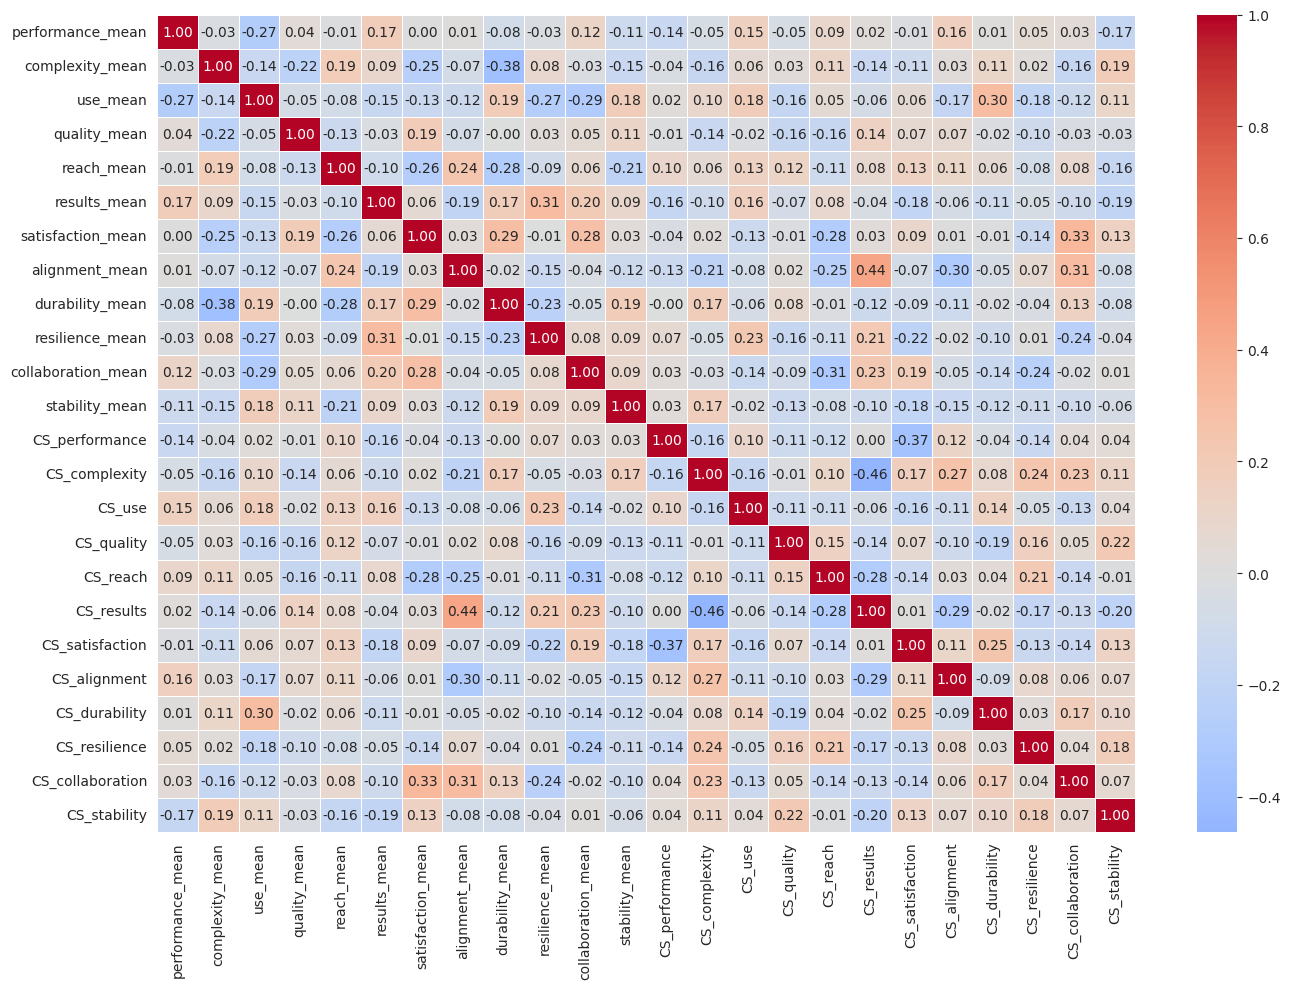

In [11]:
sns.set_style("white")

df_corr = df_project[score_cols].corr(method="spearman")

plt.figure(figsize=(14,10))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.tight_layout()
plt.show()

The exploratory analysis indicates that the synthetic dataset is structurally consistent and suitable for subsequent machine learning analyses under controlled simulation conditions. No missing values or duplicate records were identified, and the target variable presents multiple classes with moderate imbalance, reflecting the heterogeneity intentionally introduced in the simulation design.

The numerical variables show plausible distributions with limited skewness overall, while project characteristics remain sufficiently heterogeneous in terms of intervention type, classification, and number of activities.

Finally, the Spearman correlation analysis did not reveal strong pairwise monotonic associations among the explanatory variables (|ρ| ≥ 0.60). While this analysis does not capture more complex multivariate relationships, it provides an initial indication that no strong pairwise dependencies are present within the simulated dataset.

### Activity-Level Dataset

In [12]:
df = df_activity.copy()

# Basic Structure
print("Shape:", df.shape)

# Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nMissing values:\n", missing if len(missing) > 0 else "No missing values")

# Duplicates
print("\nDuplicate id_activity:", df["id_activity"].duplicated().sum())
print("Full row duplicates:", df.duplicated().sum())

Shape: (196, 21)

Missing values:
 No missing values

Duplicate id_activity: 0
Full row duplicates: 0


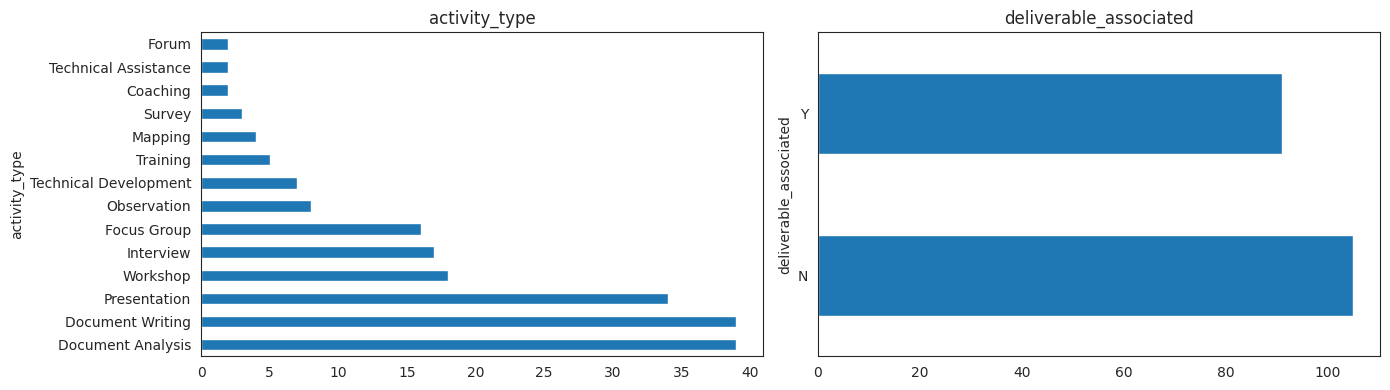

In [13]:
df = df_activity.copy()

fig, ax = plt.subplots(1, 2, figsize=(14,4))

df.activity_type.value_counts().plot.barh(ax=ax[0], title="activity_type")
df.deliverable_associated.value_counts().plot.barh(ax=ax[1], title="deliverable_associated")

plt.tight_layout()
plt.show()

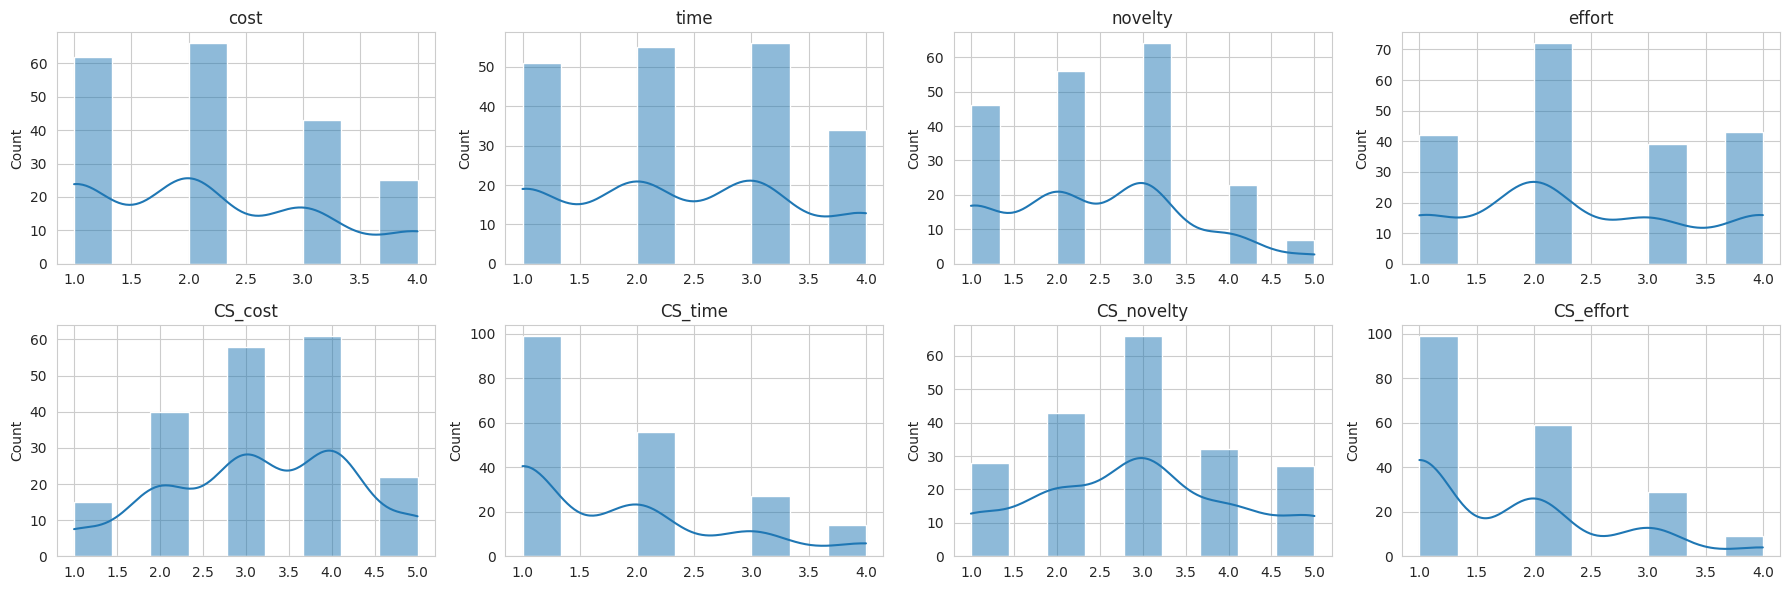

In [14]:
sns.set_style("whitegrid")

score_cols = [
"cost","time","novelty","effort",
"CS_cost","CS_time","CS_novelty","CS_effort"
]

cols = [c for c in score_cols if c in df_activity.columns]

fig, axes = plt.subplots((len(cols)+3)//4, 4, figsize=(18,3*((len(cols)+3)//4)))
axes = axes.flatten()

for i, c in enumerate(cols):
    sns.histplot(df_activity[c], kde=True, ax=axes[i])
    axes[i].set_title(c)
    axes[i].set_xlabel("")

for ax in axes[len(cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

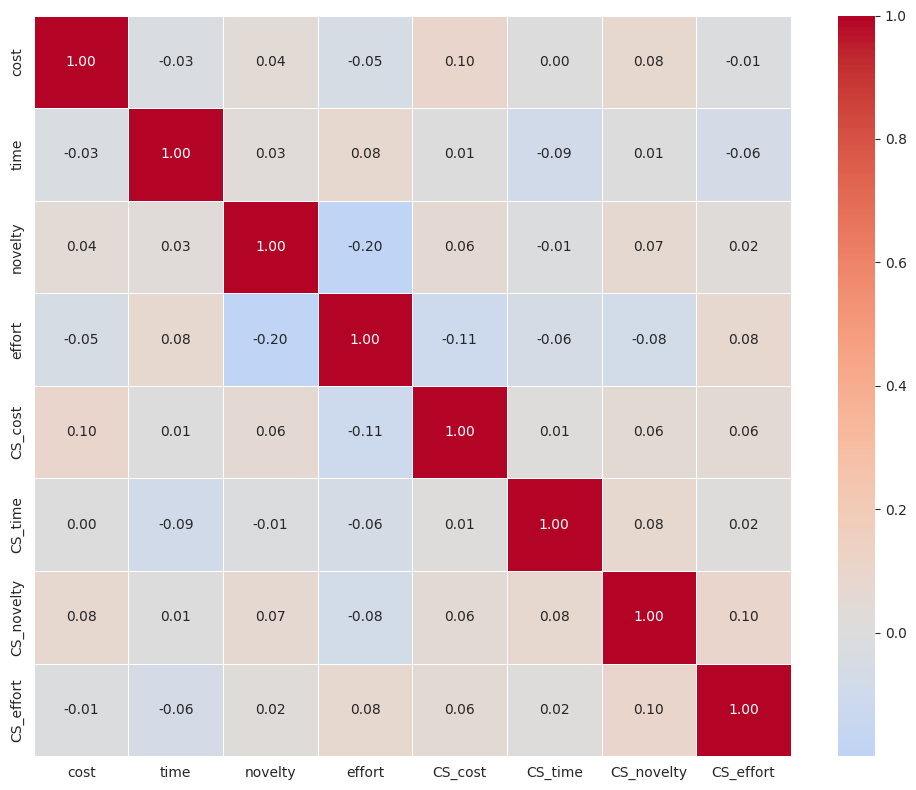

In [15]:
sns.set_style("white")

cols = [c for c in score_cols if c in df_activity.columns]

df_corr = df_activity[cols].corr(method="spearman")

plt.figure(figsize=(10,8))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)

plt.tight_layout()
plt.show()

The activity-level dataset is complete and structurally consistent, with 196 observations, no missing values, and no duplicates. Activities are mainly concentrated in document-related tasks (analysis and writing), while deliverable-associated work remains relatively distributed across categories. Contextual variables show limited variation in organization size and collaboration duration, reflecting the controlled characteristics introduced in the simulation design.

Descriptive statistics indicate moderate and centered values across activity-level dimensions (cost, time, novelty, and effort), with generally limited dispersion. Credibility scores display greater variability, particularly for time- and effort-related dimensions. Spearman correlations remain weak overall, with no strong pairwise monotonic associations detected (|ρ| ≥ 0.60), suggesting limited direct relationships between activity-level scores and their associated credibility assessments within the simulated data.

## 6-Conclusion

The activity- and project-level datasets were successfully constructed and validated through preliminary exploratory analysis. Structural checks confirmed data completeness and consistency, while descriptive analyses indicated plausible distributions and variability across the simulated variables. These prepared datasets provide the foundation for the subsequent analytical steps, including feature engineering, machine learning analyses, and explainability methods.

## 7-Data Export

In [16]:
import os

# Define export path
export_path = "/kaggle/working/"
excel_file = "simulation_ml_datasets.xlsx"
excel_path = os.path.join(export_path, excel_file)

# Ensure directory exists
os.makedirs(export_path, exist_ok=True)

# Define datasets to export
tables_to_export = {
    "Project_ML": df_project,
    "Activity_ML": df_activity
}

# Export into a single Excel file
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables_to_export.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

# Validation
print(f"ML datasets successfully created: {excel_path}")

ML datasets successfully created: /kaggle/working/simulation_ml_datasets.xlsx
